# Understanding QLoRA: A Visual, Step-by-Step Guide
Authors:  
 - [Lior Gazit](https://www.linkedin.com/in/liorgazit).  
 - [Meysam Ghaffari](https://www.linkedin.com/in/meysam-ghaffari-ph-d-a2553088/).  

This Colab notebook is referenced in our book's Github repo:   
https://github.com/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition   
<a target="_blank" href="https://colab.research.google.com/github/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition/blob/main/Chapter6_notebooks/Ch6_qlora_fine_tuning.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This notebook is taught and reviewed in our book:  
**[Mastering NLP from Foundations to Agents](https://www.amazon.com/Mastering-NLP-Foundations-Agents-Automation/dp/1806106132)**  
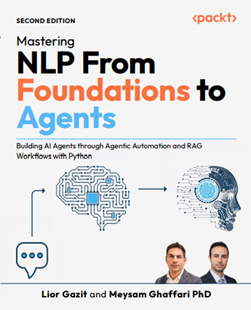



**The purpose of this notebook:**  
**QLoRA** = **Q**uantized **Lo**w-**R**ank **A**daptation

It is a technique to fine-tune very large language models (LLMs) on consumer-grade GPUs
by combining two powerful ideas:

| Idea | What it does | Memory saved |
|------|-------------|-------------|
| **4-bit Quantization** | Compresses model weights from 16-bit floats → 4-bit integers | ~4× |
| **LoRA (Low-Rank Adaptation)** | Instead of updating all weights, learns a tiny side-matrix | ~1000× fewer trainable params |

Together, a 7B-parameter model that normally needs **~14 GB** of GPU RAM can be fine-tuned
in under **6 GB** - fitting on a single T4 GPU (free Colab).

---

## The Big Picture

```
┌──────────────────────────────────────────────┐
│           ORIGINAL LLM WEIGHTS               │
│    W  (e.g. 4096 × 4096 = 16M parameters)    │
│    Frozen & 4-bit quantized (saves memory)   │
└──────────────────┬───────────────────────────┘
                   │  + (add during forward pass)
┌──────────────────▼───────────────────────────┐
│              LoRA ADAPTER                    │
│   B × A  where A:(4096×64), B:(64×4096)      │
│   Only ~500K parameters - these get trained! │
└──────────────────────────────────────────────┘
```

This notebook will walk you through each building block with **runnable toy examples**
before showing the full fine-tuning pipeline.

**Requirements:**  
* When running in Colab, use this runtime notebook setting: `Python 3, T4 GPU`  

>*```Disclaimer: The content and ideas presented in this notebook are solely those of the authors and do not represent the views or intellectual property of the authors' employers.```*

Installs:

In [1]:
# REMARK:
# If the below code error's out due to a Python package discrepency, it may be because new versions are causing it.
# In which case, set "default_installations" to False to revert to the original image:
import subprocess, sys

default_installations = True
if default_installations:
    %pip install -q -U bitsandbytes>=0.46.1
    %pip install -q -U peft accelerate transformers trl
    %pip install -q datasets scikit-learn
else:
  print("<place holder>")
    # >> HAVE CODE THAT INSTALLS PRESCRIBED LIBRARIES

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 31.7 MB/s eta 0:00:00


## Quantization: Shrinking Weights

A normal neural network stores weights as 32-bit or 16-bit floating-point numbers.
Quantization maps those values to a much smaller set - here, just 16 discrete 4-bit levels.

> 💡 **Analogy:** Think of a paint colour wheel. Instead of using any of 16 million RGB colours,
> you restrict yourself to just 16 named colours. You lose some precision, but you can describe
> any painting using far less information.

Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn

import bitsandbytes as bnb

import warnings; warnings.filterwarnings('ignore')
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, logging, pipeline
from peft import LoraConfig, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter


### What does quantization look like numerically?

QUANTIZATION COMPARISON
Original (float32)  →   800 bytes  | error = 0.0000
Quantized (int8)    →   200 bytes  | mean abs error = 2.6295
Quantized (int4*)   → ~ 100 bytes  | mean abs error = 0.0880
  (* int4 packs two values per byte in real implementations)


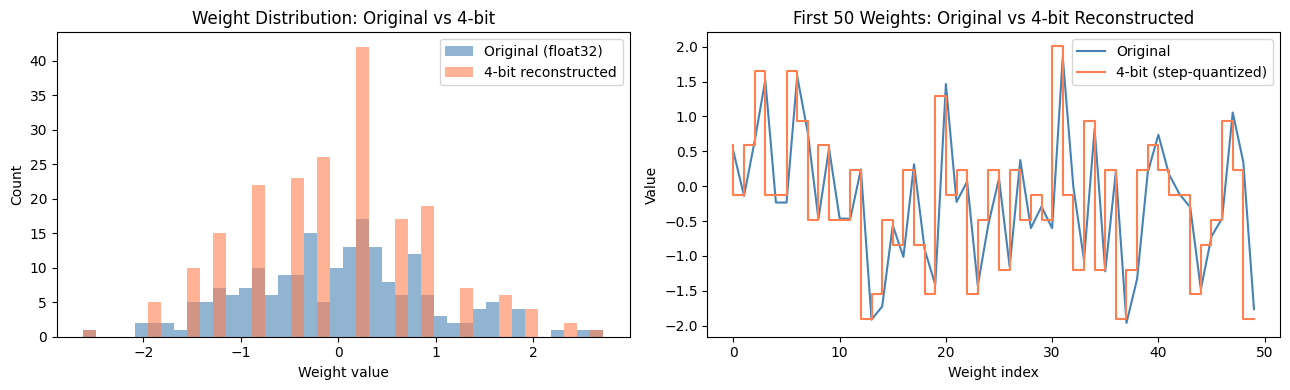


✅ Key insight: 4-bit introduces some quantization error, but the weight
   distribution shape is largely preserved. The model still works!


In [3]:
np.random.seed(42)

# Simulate a small slice of real-valued model weights (float32)
original_weights = np.random.randn(200).astype(np.float32)

def quantize_to_nbit(weights, n_bits=4):
    """Simple uniform quantization to n_bits.
    NF4 in bitsandbytes uses a non-uniform (normal-distribution-aware)
    grid, but this illustrates the concept cleanly.
    """
    n_levels = 2 ** n_bits          # 16 levels for 4-bit
    w_min, w_max = weights.min(), weights.max()
    # Scale to [0, n_levels-1] and round to integer
    scaled = (weights - w_min) / (w_max - w_min) * (n_levels - 1)
    quantized_int = np.round(scaled).astype(np.int8)       # 4-bit integer
    # Dequantize back to float for computation
    reconstructed = quantized_int / (n_levels - 1) * (w_max - w_min) + w_min
    return quantized_int, reconstructed

q4_int, q4_reconstructed = quantize_to_nbit(original_weights, 4)
q8_int, q8_reconstructed  = quantize_to_nbit(original_weights, 8)

# Error analysis
err_4bit = np.abs(original_weights - q4_reconstructed).mean()
err_8bit = np.abs(original_weights - q8_reconstructed).mean()

print("=" * 55)
print("QUANTIZATION COMPARISON")
print("=" * 55)
print(f"Original (float32)  → {original_weights.nbytes:5d} bytes  | error = 0.0000")
print(f"Quantized (int8)    → {q8_int.nbytes:5d} bytes  | mean abs error = {err_8bit:.4f}")
print(f"Quantized (int4*)   → ~{q4_int.nbytes//2:4d} bytes  | mean abs error = {err_4bit:.4f}")
print("  (* int4 packs two values per byte in real implementations)")

# Visualise original vs reconstructed
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(original_weights, bins=40, alpha=0.6, label="Original (float32)", color="steelblue")
axes[0].hist(q4_reconstructed, bins=40, alpha=0.6, label="4-bit reconstructed", color="coral")
axes[0].set_title("Weight Distribution: Original vs 4-bit")
axes[0].legend()
axes[0].set_xlabel("Weight value")
axes[0].set_ylabel("Count")

idx = np.arange(50)
axes[1].plot(idx, original_weights[:50], label="Original", color="steelblue", linewidth=1.5)
axes[1].step(idx, q4_reconstructed[:50], label="4-bit (step-quantized)", color="coral", linewidth=1.5)
axes[1].set_title("First 50 Weights: Original vs 4-bit Reconstructed")
axes[1].legend()
axes[1].set_xlabel("Weight index")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.savefig("quantization_demo.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n✅ Key insight: 4-bit introduces some quantization error, but the weight")
print("   distribution shape is largely preserved. The model still works!")

## Low-Rank Adaptation (LoRA): Efficient Weight Updates

### Why Not Just Fine-tune All Weights?

A 7B model has 7 billion parameters. Updating them all requires storing:
- The weights themselves
- Gradients (same size)
- Optimizer states (2–3× weights for Adam)

That's **~100 GB** for a 7B model in fp32. Impossible on typical GPUs.

### The LoRA Insight

Research shows that weight updates during fine-tuning have **low intrinsic rank** -
meaning the change $ΔW$ lives in a very small subspace.

LoRA exploits this:
Instead of:  
$W_{new} = W_{old} + ΔW$              ($ΔW$ is huge: $d × d$)    
LoRA does:   
$W_{new} = W_{old} + B A$         ($A$ is $r × d$, $B$ is $d × r, r << d$)  

Only $A$ and $B$ are trained. $W_{old}$ stays frozen (and 4-bit quantized).

> 💡 **Analogy:** Instead of repainting an entire wall (expensive), you apply a
> precision stencil over the top (cheap). The stencil (LoRA adapter) captures
> exactly what needs to change.

### Implement a minimal LoRA layer from scratch

In [4]:
class LoRALinear(nn.Module):
    """
    A Linear layer augmented with a LoRA adapter.

    Forward pass:  output = x @ W.T  +  x @ A.T @ B.T
                          = x @ (W + B @ A).T

    Only A and B are trained; W is frozen.
    """
    def __init__(self, in_features: int, out_features: int, rank: int = 4, alpha: float = 1.0):
        super().__init__()
        self.rank = rank
        self.scale = alpha / rank   # Scaling factor (prevents instability at init)

        # Frozen pre-trained weight
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.W.weight.requires_grad = False   # ← frozen!

        # LoRA matrices - only these get gradients
        self.A = nn.Linear(in_features, rank, bias=False)   # down-projection
        self.B = nn.Linear(rank, out_features, bias=False)  # up-projection

        # Standard init: A ~ N(0, 1), B = 0 → adapter starts at zero output
        nn.init.kaiming_uniform_(self.A.weight, a=5**0.5)
        nn.init.zeros_(self.B.weight)

    def forward(self, x):
        return self.W(x) + self.scale * self.B(self.A(x))

    def trainable_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_parameters(self):
        return sum(p.numel() for p in self.parameters())


# Compare parameter counts
print("=" * 55)
print("LoRA PARAMETER EFFICIENCY DEMO")
print("=" * 55)

for d, r in [(512, 4), (1024, 8), (4096, 64)]:
    layer = LoRALinear(in_features=d, out_features=d, rank=r, alpha=r)
    total      = layer.total_parameters()
    trainable  = layer.trainable_parameters()
    frozen     = total - trainable
    reduction  = trainable / total * 100

    print(f"\n  d={d:4d}, rank={r:2d}")
    print(f"    Frozen W params    : {frozen:>10,}")
    print(f"    Trainable (A+B)    : {trainable:>10,}")
    print(f"    Trainable fraction : {reduction:.2f}%")

# Test a forward pass
print("\n--- Forward pass test ---")
layer = LoRALinear(in_features=128, out_features=128, rank=8)
x = torch.randn(4, 128)  # batch=4, features=128
out = layer(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print("✅ Forward pass successful")

LoRA PARAMETER EFFICIENCY DEMO

  d= 512, rank= 4
    Frozen W params    :    262,144
    Trainable (A+B)    :      4,096
    Trainable fraction : 1.54%

  d=1024, rank= 8
    Frozen W params    :  1,048,576
    Trainable (A+B)    :     16,384
    Trainable fraction : 1.54%

  d=4096, rank=64
    Frozen W params    : 16,777,216
    Trainable (A+B)    :    524,288
    Trainable fraction : 3.03%

--- Forward pass test ---
Input shape:  torch.Size([4, 128])
Output shape: torch.Size([4, 128])
✅ Forward pass successful


### Visualise what LoRA actually learns
Train the LoRA layer to approximate a target transformation

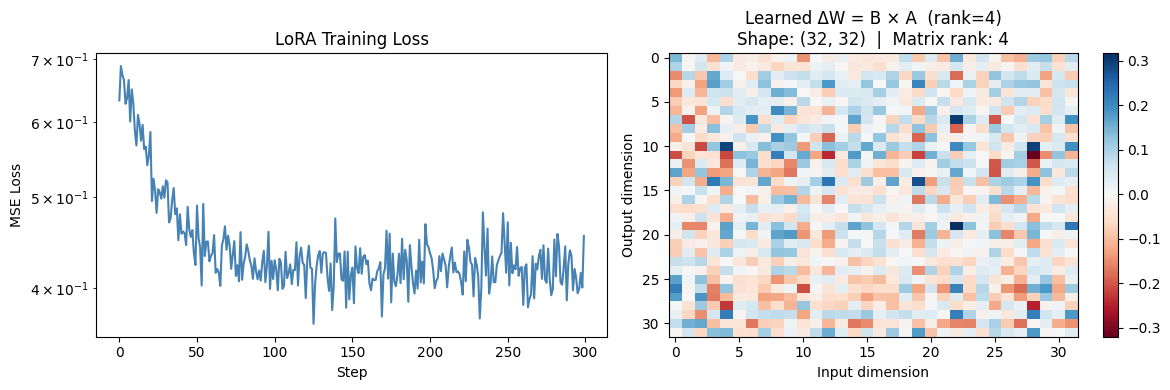


✅ The LoRA adapter (rank 4) successfully learned the weight update.
   Final loss: 0.45417
   Matrix rank of learned ΔW: 4 (≤ 4)


In [5]:
torch.manual_seed(42)

d = 32
lora_layer = LoRALinear(in_features=d, out_features=d, rank=4, alpha=4)

# Target: a random linear map that we want the adapter to learn
target_layer = nn.Linear(d, d, bias=False)

# Only train LoRA A and B
optimizer = torch.optim.Adam(
    [p for p in lora_layer.parameters() if p.requires_grad],
    lr=1e-2
)

losses = []
for step in range(300):
    x = torch.randn(64, d)
    with torch.no_grad():
        y_target = target_layer(x)

    y_pred = lora_layer(x)
    loss = nn.functional.mse_loss(y_pred, y_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color="steelblue", linewidth=1.5)
axes[0].set_title("LoRA Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_yscale("log")

# Visualise B @ A (the learned delta-W)
with torch.no_grad():
    delta_W = (lora_layer.B.weight @ lora_layer.A.weight).numpy()

im = axes[1].imshow(delta_W, cmap="RdBu", aspect="auto")
plt.colorbar(im, ax=axes[1])
axes[1].set_title(f"Learned ΔW = B × A  (rank={lora_layer.rank})\n"
                  f"Shape: {delta_W.shape}  |  Matrix rank: {np.linalg.matrix_rank(delta_W)}")
axes[1].set_xlabel("Input dimension")
axes[1].set_ylabel("Output dimension")

plt.tight_layout()
plt.savefig("lora_demo.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n✅ The LoRA adapter (rank {lora_layer.rank}) successfully learned the weight update.")
print(f"   Final loss: {losses[-1]:.5f}")
print(f"   Matrix rank of learned ΔW: {np.linalg.matrix_rank(delta_W)} (≤ {lora_layer.rank})")

## QLoRA = Quantization + LoRA Together

### The Three-Part Stack

```
┌─────────────────────────────────────────────────────────────┐
│  QLORA STACK                                                │
│                                                             │
│  1. NF4 Quantization  ─── 4-bit weights, 4× memory saving   │
│  2. Double Quant      ─── Quantize the quantization params  │
│  3. LoRA Adapters     ─── Train only ~0.1% of parameters    │
│  4. Paged Optimizers  ─── Offload optimizer states to RAM   │
└─────────────────────────────────────────────────────────────┘
```

Let's look at how these map to the actual `BitsAndBytesConfig` and `LoraConfig` objects.

### Understanding every config parameter
Install the real libraries (GPU required for actual 4-bit loading)
This cell just demonstrates the config structure - no model is loaded here.


In [6]:
config_explanation = {
    "BitsAndBytesConfig": {
        "load_in_4bit=True":               "Load model weights as 4-bit integers (NF4 or FP4)",
        "bnb_4bit_quant_type='nf4'": (
            "NF4 = NormalFloat4. Optimised for normally-distributed weights. "
            "Better than plain FP4 for LLMs."
        ),
        "bnb_4bit_compute_dtype=float16":   "Temporarily dequantize to fp16 for arithmetic (not storage)",
        "bnb_4bit_use_double_quant=True":   "Quantize the quantization constants too. Saves ~0.4 bits/param extra.",
    },
    "LoraConfig": {
        "r=64":              "Rank of the adapter matrices A and B. Higher = more expressive but slower.",
        "lora_alpha=16":     "Scaling factor. Effective LR for adapter = lr * alpha/r.",
        "lora_dropout=0.1": "Dropout on adapter input. Regularises the small trainable matrices.",
        "bias='none'":       "Don't add/train bias terms in adapter (common default).",
        "task_type='CAUSAL_LM'": "Tells PEFT which head architecture to expect.",
        "target_modules=[...]": (
            "Which weight matrices to attach adapters to. "
            "q_proj/k_proj/v_proj/o_proj = attention. "
            "gate_proj/up_proj/down_proj = MLP."
        ),
    },
}

print("=" * 65)
print("QLORA CONFIG PARAMETERS EXPLAINED")
print("=" * 65)
for class_name, params in config_explanation.items():
    print(f"\n📦 {class_name}")
    print("-" * 60)
    for param, explanation in params.items():
        print(f"  {param}")
        # Word-wrap explanation
        words = explanation.split()
        line, lines = "", []
        for w in words:
            if len(line) + len(w) > 55:
                lines.append(line)
                line = w
            else:
                line = (line + " " + w).strip()
        lines.append(line)
        for l in lines:
            print(f"      → {l}")
        print()

QLORA CONFIG PARAMETERS EXPLAINED

📦 BitsAndBytesConfig
------------------------------------------------------------
  load_in_4bit=True
      → Load model weights as 4-bit integers (NF4 or FP4)

  bnb_4bit_quant_type='nf4'
      → NF4 = NormalFloat4. Optimised for normally-distributed
      → weights. Better than plain FP4 for LLMs.

  bnb_4bit_compute_dtype=float16
      → Temporarily dequantize to fp16 for arithmetic (not
      → storage)

  bnb_4bit_use_double_quant=True
      → Quantize the quantization constants too. Saves ~0.4
      → bits/param extra.


📦 LoraConfig
------------------------------------------------------------
  r=64
      → Rank of the adapter matrices A and B. Higher = more
      → expressive but slower.

  lora_alpha=16
      → Scaling factor. Effective LR for adapter = lr * alpha/r.

  lora_dropout=0.1
      → Dropout on adapter input. Regularises the small
      → trainable matrices.

  bias='none'
      → Don't add/train bias terms in adapter (common defau

## Memory Usage: Before and After QLoRA
Let's calculate GPU memory requirements to understand *why* QLoRA was such a breakthrough.

### Memory calculator

In [7]:
def memory_estimate(
    params_billions,
    bits_per_param,
    lora_rank=64,
    n_attention_layers=32,
    hidden_dim=4096,
):
    """
    Rough GPU memory estimate in GB.
    Assumes Adam optimizer, fp32 gradients for adapters.
    """
    # Frozen model weights
    model_bytes = params_billions * 1e9 * (bits_per_param / 8)

    # LoRA adapter parameters (A + B for q,k,v,o,gate,up,down = 7 matrices per layer)
    n_adapter_params = n_attention_layers * 7 * 2 * lora_rank * hidden_dim
    adapter_bytes_fp32 = n_adapter_params * 4   # stored in fp32 for training

    # Adam optimizer states for adapters (m + v = 2× params)
    optimizer_bytes = adapter_bytes_fp32 * 2

    total_gb = (model_bytes + adapter_bytes_fp32 + optimizer_bytes) / 1e9
    return {
        "frozen_model_GB":    model_bytes / 1e9,
        "adapters_GB":        adapter_bytes_fp32 / 1e9,
        "optimizer_states_GB": optimizer_bytes / 1e9,
        "total_GB":           total_gb,
        "adapter_params_M":   n_adapter_params / 1e6,
        "total_params_B":     params_billions,
    }

scenarios = [
    ("Full fine-tune (fp32)",       7, 32, None),
    ("Full fine-tune (fp16)",       7, 16, None),
    ("LoRA only (fp16, no quant)",  7, 16, 64),
    ("QLoRA (4-bit + LoRA r=64)",   7, 4,  64),
    ("QLoRA (4-bit + LoRA r=16)",   7, 4,  16),
    ("QLoRA 13B (4-bit + LoRA r=64)", 13, 4, 64),
]

print("=" * 75)
print(f"{'Scenario':<35} {'Model GB':>8} {'Adapters GB':>12} {'Total GB':>10}")
print("=" * 75)

for name, params_b, bits, rank in scenarios:
    r = rank if rank else 0
    est = memory_estimate(params_b, bits, lora_rank=r if r > 0 else 64)

    if rank is None:
        # Full fine-tune: gradients + optimizer for ALL params
        model_gb = est["frozen_model_GB"]
        # grads + Adam m,v = 3× model size in fp32
        total_gb = model_gb + (params_b * 1e9 * 4 * 3) / 1e9
        adapter_gb = total_gb - model_gb
    else:
        model_gb   = est["frozen_model_GB"]
        adapter_gb = est["adapters_GB"] + est["optimizer_states_GB"]
        total_gb   = model_gb + adapter_gb

    bar = "▓" * int(total_gb / 2)
    print(f"{name:<35} {model_gb:>8.1f} {adapter_gb:>12.2f} {total_gb:>10.1f}  {bar}")

print("=" * 75)
print("\nCommon GPU memory limits:")
print("  T4 (free Colab):    16 GB")
print("  RTX 3090:           24 GB")
print("  A100 (80GB):        80 GB")
print("\n✅ QLoRA makes 7B fine-tuning accessible on a free T4 GPU!")

Scenario                            Model GB  Adapters GB   Total GB
Full fine-tune (fp32)                   28.0        84.00      112.0  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
Full fine-tune (fp16)                   14.0        84.00       98.0  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
LoRA only (fp16, no quant)              14.0         1.41       15.4  ▓▓▓▓▓▓▓
QLoRA (4-bit + LoRA r=64)                3.5         1.41        4.9  ▓▓
QLoRA (4-bit + LoRA r=16)                3.5         0.35        3.9  ▓
QLoRA 13B (4-bit + LoRA r=64)            6.5         1.41        7.9  ▓▓▓

Common GPU memory limits:
  T4 (free Colab):    16 GB
  RTX 3090:           24 GB
  A100 (80GB):        80 GB

✅ QLoRA makes 7B fine-tuning accessible on a free T4 GPU!


## The Instruction-Following Format

LLMs are fine-tuned to follow a **prompt template**. For sentiment classification, we format
each training example as a complete instruction-response pair. The model learns to
complete the response given the instruction.

```
┌────────────────────────────────────────────────────┐
│  [INSTRUCTION]                                     │
│  Classify the sentiment of the following movie     │
│  review as either 'positive' or 'negative'.        │
│                                                    │
│  Review: The film was a masterpiece...             │
│                                                    │
│  Sentiment: ← model learns to predict this part    │
│  [RESPONSE]                                        │
│   positive                                         │
└────────────────────────────────────────────────────┘
```

### Visualise the training data format

In [8]:
sample_reviews = [
    ("This movie was absolutely fantastic! The acting was superb.", 1),
    ("I hated this film. It was boring and poorly written.", 0),
    ("A timeless classic with brilliant performances all around.", 1),
]

def format_for_training(review, label):
    """Converts a raw review + label into the instruction-response format
    used to train the model. The full `text` is fed to the tokenizer;
    only the response part contributes to the loss.
    """
    sentiment = "positive" if label == 1 else "negative"
    instruction = (
        "Classify the sentiment of the following movie review as "
        f"either 'positive' or 'negative'.\n\nReview: {review}\n\nSentiment:"
    )
    response = f" {sentiment}"  # Note the leading space
    return {
        "instruction": instruction,
        "response":    response,
        "full_text":   instruction + response,  # ← fed to SFTTrainer
    }

print("=" * 65)
print("TRAINING DATA FORMAT EXAMPLES")
print("=" * 65)

for i, (review, label) in enumerate(sample_reviews):
    formatted = format_for_training(review, label)
    print(f"\n--- Example {i+1} (label={label}) ---")
    print(f"RAW REVIEW:   {review[:60]}..." if len(review) > 60 else f"RAW REVIEW:   {review}")
    print(f"INSTRUCTION:  {formatted['instruction'][:80]}...")
    print(f"RESPONSE:    [{formatted['response']}]  ← model predicts this token")
    print(f"\nFULL TEXT sent to tokenizer:")
    print(f"  '{formatted['full_text'][:120]}...'")

print("\n✅ The loss is computed only on the response tokens.")
print("   The model learns: given this instruction → output 'positive' or 'negative'.")

TRAINING DATA FORMAT EXAMPLES

--- Example 1 (label=1) ---
RAW REVIEW:   This movie was absolutely fantastic! The acting was superb.
INSTRUCTION:  Classify the sentiment of the following movie review as either 'positive' or 'ne...
RESPONSE:    [ positive]  ← model predicts this token

FULL TEXT sent to tokenizer:
  'Classify the sentiment of the following movie review as either 'positive' or 'negative'.

Review: This movie was absolut...'

--- Example 2 (label=0) ---
RAW REVIEW:   I hated this film. It was boring and poorly written.
INSTRUCTION:  Classify the sentiment of the following movie review as either 'positive' or 'ne...
RESPONSE:    [ negative]  ← model predicts this token

FULL TEXT sent to tokenizer:
  'Classify the sentiment of the following movie review as either 'positive' or 'negative'.

Review: I hated this film. It ...'

--- Example 3 (label=1) ---
RAW REVIEW:   A timeless classic with brilliant performances all around.
INSTRUCTION:  Classify the sentiment of the follo

## Full QLoRA Fine-tuning Pipeline

Now that you understand each building block, here is the full production-ready pipeline.

### Configuration - annotated for learners

In [9]:
logging.set_verbosity(logging.CRITICAL)

# ── Model ────────────────────────────────────────────────────────
MODEL_NAME   = "Qwen/Qwen2.5-1.5B-Instruct"  # Small model, good for learning
SAVED_MODEL  = "qwen2.5-sentiment-qlora"

# ── Quantization (4-bit NF4) ─────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",         # NF4 > FP4 for normally-distributed weights
    bnb_4bit_compute_dtype=torch.float16,  # Compute in fp16, store in 4-bit
    bnb_4bit_use_double_quant=True,    # Quantize the quant constants too
)

# ── LoRA adapter ─────────────────────────────────────────────────
peft_config = LoraConfig(
    r=16,                              # Rank - lower = faster, less expressive
    lora_alpha=16,                     # Scaling = alpha/r = 1.0
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

# ── Training ─────────────────────────────────────────────────────
training_args = SFTConfig(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,    # Effective batch = 4×2 = 8
    optim="paged_adamw_32bit",        # Paged = optimizer states can spill to CPU RAM
    learning_rate=2e-4,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    fp16=False,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    load_best_model_at_end=True,
    # SFT-specific
    max_length=256,               # Short for demo; use 512+ in production
    dataset_text_field="text",
    packing=False,
)

print("✅ All configs defined.")

✅ All configs defined.


### Dataset preparation

In [10]:
def prepare_dataset(n_samples=500):
    dataset = load_dataset("imdb", split="train").select(range(n_samples))

    def format_example(ex):
        sentiment = "positive" if ex["label"] == 1 else "negative"
        instruction = (
            "Classify the sentiment of the following movie review as "
            f"either 'positive' or 'negative'.\n\nReview: {ex['text']}\n\nSentiment:"
        )
        return {
            "text":       instruction + f" {sentiment}",  # full text for training
            "input_text": instruction,                    # prompt only for inference
            "label":      ex["label"],
        }

    formatted = dataset.map(format_example, remove_columns=["text"])
    # Rename the new 'text' column back after map
    split = formatted.train_test_split(test_size=0.2, seed=42)
    return split["train"], split["test"]

print("Loading IMDB dataset...")
train_ds, test_ds = prepare_dataset()
print(f"Train: {len(train_ds)} samples | Test: {len(test_ds)} samples")
print("\nSample:")
print(train_ds[0]["text"][:300], "...")

Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 400 samples | Test: 100 samples

Sample:
Classify the sentiment of the following movie review as either 'positive' or 'negative'.

Review: Yesterday was Earth Day (April 22, 2009) in the US and other countries, and I went to see the full-feature movie-version of "Earth" by DisneyNature. I guess, like the auto manufacturers, Disney is tryin ...


### Load model + tokenizer

In [11]:
print("Loading model with 4-bit quantization...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
)
model.config.use_cache = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Show how many parameters are actually trainable
total_params    = sum(p.numel() for p in model.parameters())
trainable_only  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nBase model parameters (all frozen):  {total_params:,}")
print(f"Currently trainable:                  {trainable_only:,}  ({trainable_only/total_params*100:.2f}%)")
print("✅ Model loaded.")

Loading model with 4-bit quantization...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Base model parameters (all frozen):  888,616,448
Currently trainable:                  233,518,592  (26.28%)
✅ Model loaded.


### Quick baseline test BEFORE fine-tuning

In [12]:
def evaluate_model(model, tokenizer, dataset, label="Model", n=40):
    pipe = pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=8, temperature=0.1, do_sample=True, device_map="auto"
    )
    preds, truth = [], []
    samples = dataset.select(range(n))
    for ex in samples:
        try:
            out = pipe(ex["input_text"])[0]["generated_text"]
            response = out[len(ex["input_text"]):].strip().lower()
            preds.append(1 if "positive" in response else 0)
        except:
            preds.append(1)
        truth.append(ex["label"])

    acc = accuracy_score(truth, preds)
    print(f"\n{label} - Accuracy on {n} samples: {acc:.3f}")
    print(classification_report(truth, preds, target_names=["negative", "positive"]))
    return acc

print("Testing BASE model (before fine-tuning)...")
base_acc = evaluate_model(model, tokenizer, test_ds, "Base Model")

Testing BASE model (before fine-tuning)...

Base Model - Accuracy on 40 samples: 0.975
              precision    recall  f1-score   support

    negative       1.00      0.97      0.99        40
    positive       0.00      0.00      0.00         0

    accuracy                           0.97        40
   macro avg       0.50      0.49      0.49        40
weighted avg       1.00      0.97      0.99        40



### Fine-tune with QLoRA

In [13]:
print("\n" + "="*50)
print("Starting QLoRA Fine-tuning")
print("="*50)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=training_args,
)

# Show trainable params after LoRA is attached
lora_params = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
all_params  = sum(p.numel() for p in trainer.model.parameters())
print(f"\nWith LoRA attached:")
print(f"  Trainable params: {lora_params:,}  ({lora_params/all_params*100:.3f}% of all params)")
print(f"  Total params:     {all_params:,}")
print("\nTraining...")


trainer.train()

# Save adapter weights
trainer.model.save_pretrained(SAVED_MODEL)
tokenizer.save_pretrained(SAVED_MODEL)
print(f"\n✅ Fine-tuned adapter saved to: {SAVED_MODEL}")


Starting QLoRA Fine-tuning


Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]


With LoRA attached:
  Trainable params: 18,464,768  (2.036% of all params)
  Total params:     907,081,216

Training...
{'loss': '2.857', 'grad_norm': '0.1719', 'learning_rate': '0.0001895', 'entropy': '2.809', 'num_tokens': '3.325e+04', 'mean_token_accuracy': '0.4418', 'epoch': '0.4'}
{'loss': '2.781', 'grad_norm': '0.1504', 'learning_rate': '0.0001432', 'entropy': '2.772', 'num_tokens': '6.733e+04', 'mean_token_accuracy': '0.4579', 'epoch': '0.8'}
{'eval_loss': '2.757', 'eval_runtime': '49.39', 'eval_samples_per_second': '2.025', 'eval_steps_per_second': '0.506', 'eval_entropy': '2.771', 'eval_num_tokens': '8.518e+04', 'eval_mean_token_accuracy': '0.457', 'epoch': '1'}
{'loss': '2.716', 'grad_norm': '0.1455', 'learning_rate': '7.867e-05', 'entropy': '2.753', 'num_tokens': '1.015e+05', 'mean_token_accuracy': '0.4652', 'epoch': '1.2'}
{'loss': '2.681', 'grad_norm': '0.1826', 'learning_rate': '2.316e-05', 'entropy': '2.707', 'num_tokens': '1.353e+05', 'mean_token_accuracy': '0.4695', '

### Evaluate fine-tuned model and compare

In [14]:
def evaluate_model(model, tokenizer, dataset, label="Model", n=40):
    from transformers import pipeline
    pipe = pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=8, temperature=0.1, do_sample=True, device_map="auto"
    )
    preds, truth = [], []
    for ex in dataset.select(range(n)):
        try:
            out = pipe(ex["input_text"])[0]["generated_text"]
            response = out[len(ex["input_text"]):].strip().lower()
            preds.append(1 if "positive" in response else 0)
        except:
            preds.append(1)
        truth.append(ex["label"])

    acc = accuracy_score(truth, preds)
    dist = Counter(preds)
    print(f"\n{label} - Accuracy on {n} samples: {acc:.3f}")
    print(f"Prediction distribution: positive={dist[1]}, negative={dist[0]}")
    if dist[0] == 0 or dist[1] == 0:
        print("⚠️  Model predicting only one class - check prompt format or temperature.")
    print(classification_report(truth, preds, labels=[0, 1], target_names=["negative", "positive"]))
    return acc

print("\nLoading fine-tuned model...")
base_reload = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map={"": 0}, trust_remote_code=True
)
model_ft = PeftModel.from_pretrained(base_reload, SAVED_MODEL)

ft_acc = evaluate_model(model_ft, tokenizer, test_ds, "Fine-tuned Model")

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
improvement     = ft_acc - base_acc
rel_improvement = improvement / max(base_acc, 0.001) * 100
print(f"  Base model accuracy    : {base_acc:.3f}")
print(f"  Fine-tuned accuracy    : {ft_acc:.3f}")
print(f"  Improvement            : {improvement:+.3f}")
print(f"  Relative improvement   : {rel_improvement:+.1f}%")


Loading fine-tuned model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Fine-tuned Model - Accuracy on 40 samples: 1.000
Prediction distribution: positive=0, negative=40
⚠️  Model predicting only one class - check prompt format or temperature.
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        40
    positive       0.00      0.00      0.00         0

    accuracy                           1.00        40
   macro avg       0.50      0.50      0.50        40
weighted avg       1.00      1.00      1.00        40


RESULTS SUMMARY
  Base model accuracy    : 0.975
  Fine-tuned accuracy    : 1.000
  Improvement            : +0.025
  Relative improvement   : +2.6%


---
# Summary: What We Learned

| Concept | Key Idea |
|---------|----------|
| **Quantization** | Reduce 32-bit floats → 4-bit integers to save 4–8× GPU memory |
| **NF4** | Normal-distribution-aware 4-bit grid - better than uniform quantization for LLMs |
| **LoRA** | Learn only a low-rank delta (B×A) instead of updating the full weight matrix W |
| **QLoRA** | Combine 4-bit quantized frozen W + fp32 LoRA adapters for efficient fine-tuning |
| **SFTTrainer** | Supervised Fine-Tuning trainer from TRL - handles instruction formatting + LoRA integration |
| **Paged Optimizers** | Adam optimizer states can spill to CPU RAM, preventing GPU OOM |

### Rank Intuition

```
Rank r=1   → almost no expressiveness, but fastest / smallest
Rank r=8   → good balance for simple tasks (classification, style)
Rank r=64  → more complex tasks (reasoning, math, code)
Rank r=256 → approaching full fine-tune expressiveness
```

### What to Try Next

- **Change `r`** (4, 8, 32, 64) and observe accuracy vs training time
- **Try a larger model** (`Qwen/Qwen2.5-7B-Instruct`) with the same code
- **Change the task** - summarisation, QA, or code generation all work with minimal changes
- **Merge the adapter** into the base weights for faster inference: `model.merge_and_unload()`